# FastQC Quality Distribution

        ## Manuscript targets
        - `Results / Quality assessment`
- `Figure: quality distribution`

        ## Primary inputs
        - `share/results/technical/per_srr_quality.tsv`
- `data/flattened_fastqc_raw/ or share/data/flattened_fastqc_raw/`

        ## Rebuild scripts
        - `share/scripts/analysis/01_extract_per_srr_fastqc_metrics.py`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

The manuscript compares average per-sample quality against the quality measured at the tail of the read. The persistent summary table already stores mean quality, while the terminal-quality distribution is reconstructed here from the raw FastQC reports when the local full dataset is available.


In [1]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    # --- Standardized Plotting Configuration ---
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })
    sns.set_theme(style="whitegrid", palette="colorblind")
    plt.rcParams.update({"font.family": "sans-serif"})
    # -------------------------------------------
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [2]:
REBUILD = False
if REBUILD:
    run_script("share/scripts/analysis/01_extract_per_srr_fastqc_metrics.py")

quality = load_terminal_quality_table()
quality[["SRR_ID", "project_id", "Q_mean", "terminal_q_mean", "tail_quality_decay"]].head()


,SRR_ID,project_id,Q_mean,terminal_q_mean,tail_quality_decay
0,SRR11263449,PRJNA610985,39.002506,38.204278,0.798228
1,SRR11263450,PRJNA610985,38.991934,38.222602,0.769332
2,SRR11263451,PRJNA610985,38.994559,38.194844,0.799715
3,SRR11263452,PRJNA610985,38.998604,38.235053,0.763551
4,SRR11263453,PRJNA610985,39.004588,38.229488,0.775099


In [3]:
summary = pd.Series(
    {
        "n_samples": len(quality),
        "median_Q_mean": quality["Q_mean"].median(),
        "median_terminal_q_mean": quality["terminal_q_mean"].median(),
        "min_Q_mean": quality["Q_mean"].min(),
        "min_terminal_q_mean": quality["terminal_q_mean"].min(),
    }
)
display(summary.to_frame("value"))


,value
n_samples,830.000000
median_Q_mean,36.040464
median_terminal_q_mean,35.170160
min_Q_mean,22.553456
min_terminal_q_mean,17.499404


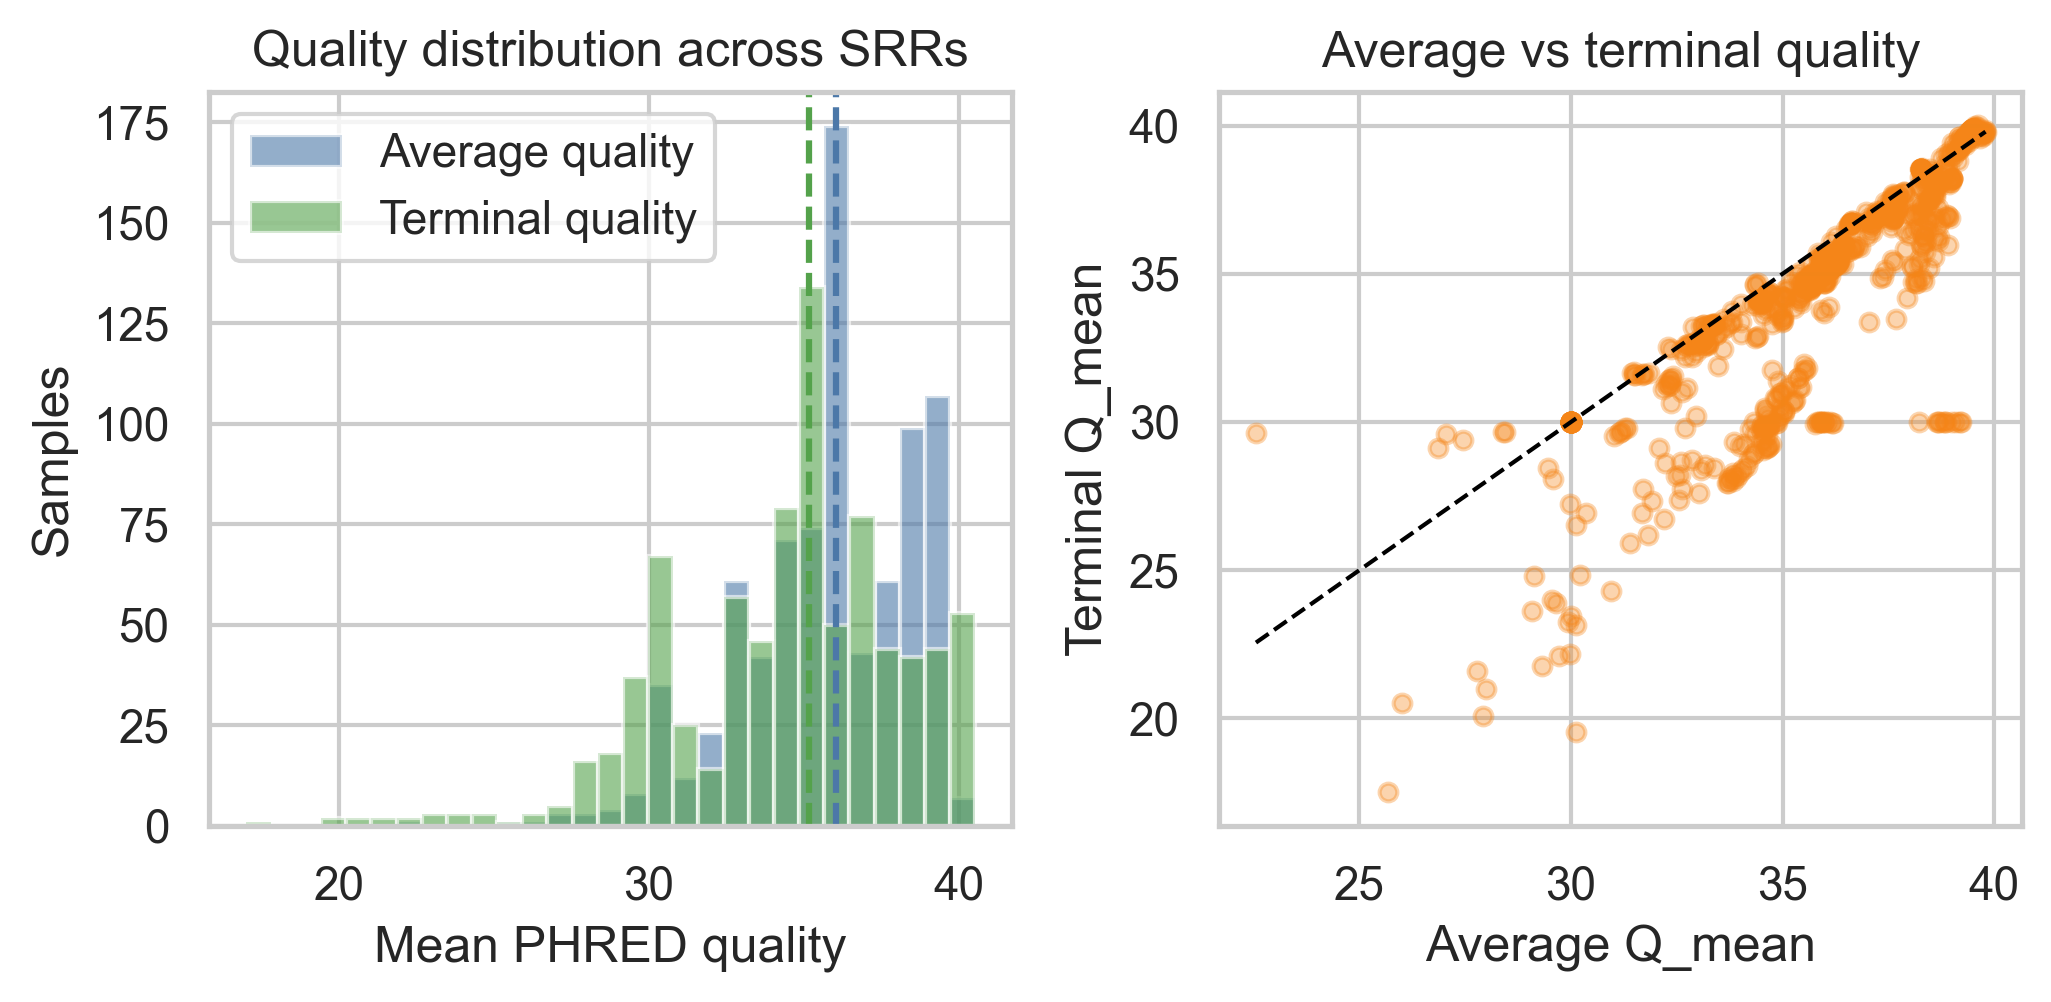

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))

bins = np.linspace(
    min(quality["terminal_q_mean"].min(), quality["Q_mean"].min()) - 0.5,
    max(quality["terminal_q_mean"].max(), quality["Q_mean"].max()) + 0.5,
    30,
)
axes[0].hist(quality["Q_mean"], bins=bins, alpha=0.6, label="Average quality", color="#4C78A8")
axes[0].hist(quality["terminal_q_mean"], bins=bins, alpha=0.6, label="Terminal quality", color="#54A24B")
axes[0].axvline(quality["Q_mean"].median(), color="#4C78A8", linestyle="--")
axes[0].axvline(quality["terminal_q_mean"].median(), color="#54A24B", linestyle="--")
axes[0].set_title("Quality distribution across SRRs")
axes[0].set_xlabel("Mean PHRED quality")
axes[0].set_ylabel("Samples")
axes[0].legend()

axes[1].scatter(
    quality["Q_mean"],
    quality["terminal_q_mean"],
    alpha=0.35,
    s=18,
    color="#F58518",
)
axes[1].plot(
    [quality["Q_mean"].min(), quality["Q_mean"].max()],
    [quality["Q_mean"].min(), quality["Q_mean"].max()],
    linestyle="--",
    color="black",
    linewidth=1,
)
axes[1].set_title("Average vs terminal quality")
axes[1].set_xlabel("Average Q_mean")
axes[1].set_ylabel("Terminal Q_mean")

fig.tight_layout()
plt.show()
